# SSH 모델의 밴드구조와 위상 — Tight-Binding 계산

전산물리학 중간 프로젝트 · 신효산

**이 노트북이 보이려는 것 (한 문장)**
> 갭 크기가 같은 두 사슬이 위상수 $\nu$로 구별되고, $\nu=1$인 사슬만 끝에 $E\approx0$ 에지 상태를 갖는다.

**진행 순서**: 단원자 사슬(베이스라인) → SSH 밴드 → 밴드갭 → 위상수 → 유한 사슬 에지 상태

각 절은 **예측 → 실행 → 확인 → 질문** 순서로 진행한다.

## 0. 설정

단위는 $a=1$, $\hbar=1$로 둔다. 에너지 단위는 hopping $t$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A_LATTICE = 1.0
plt.rcParams["figure.dpi"] = 110

## 1. 베이스라인: 1D 단원자 사슬

원자가 한 종류인 사슬. Bloch 안자 $|k\rangle=\sum_n e^{ikna}|n\rangle$를 해밀토니안에 넣으면

$$E(k)=\epsilon_0-2t\cos(ka)$$

**예측**: $k=0$과 $k=\pi/a$에서 $E$는 각각 얼마인가? 밴드 폭은?

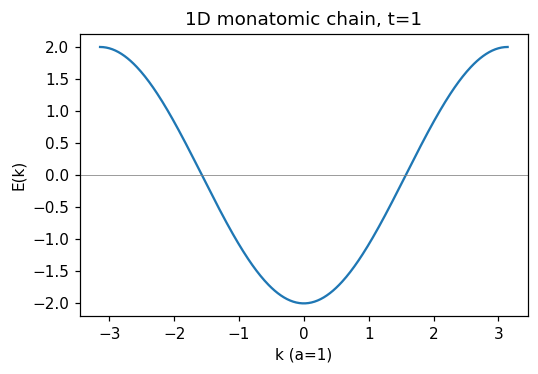

E(k=0)  = -2.0
E(k=pi) = 2.0
밴드 폭  = 4.0 (= 4t)


In [2]:
def monatomic_energy(k, t=1.0, eps0=0.0, a=A_LATTICE):
    return eps0 - 2 * t * np.cos(k * a)

k_vals = np.linspace(-np.pi, np.pi, 400)
E = monatomic_energy(k_vals)

plt.figure(figsize=(5, 3.5))
plt.plot(k_vals, E)
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("k (a=1)"); plt.ylabel("E(k)")
plt.title("1D monatomic chain, t=1")
plt.tight_layout(); plt.show()

print("E(k=0)  =", monatomic_energy(0.0))
print("E(k=pi) =", monatomic_energy(np.pi))
print("밴드 폭  =", monatomic_energy(np.pi) - monatomic_energy(0.0), "(= 4t)")

**확인**: 밴드 바닥 $-2t$, 꼭대기 $+2t$, 폭 $4t$.
원자당 전자 1개면 밴드가 정확히 반만 차므로 이 사슬은 **금속**이다.

### 1-2. 행렬 대각화로 직접 확인 (주기경계조건)

해석식이 맞는지, **실공간 $N\times N$ 해밀토니안**을 직접 대각화해서 확인한다.
원자 $N$개를 고리로 이으면(주기경계조건) 허용되는 파수는 $k=\dfrac{2\pi m}{Na},\ m=0,\dots,N-1$ 이고, 고유값이 해석식 $E(k)$와 같아야 한다.

**예측**: 수치 고유값과 해석식의 차이는 어느 정도인가? $N$이 짝수일 때와 홀수일 때 꼭대기 에너지는 어떻게 다른가?

N=20: 수치 고유값과 해석식 E(k_m)의 최대 차이 = 1.11e-15


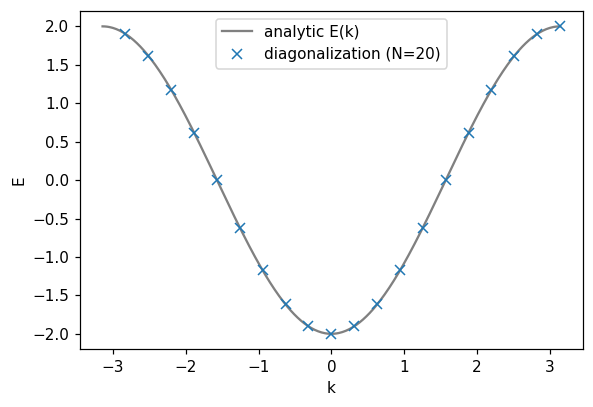

N=  20: 최대 에너지 = 2.00000   (연속 극한 2.0)
N=  21: 최대 에너지 = 1.97766   (연속 극한 2.0)
N= 200: 최대 에너지 = 2.00000   (연속 극한 2.0)
N= 201: 최대 에너지 = 1.99976   (연속 극한 2.0)


In [3]:
def ring_hamiltonian(N, t=1.0, eps0=0.0):
    H = np.eye(N) * eps0
    for n in range(N):
        H[n, (n + 1) % N] = H[(n + 1) % N, n] = -t       # 주기경계조건: 마지막 원자가 첫 원자와 연결
    return H

N = 20
E_num = np.sort(np.linalg.eigvalsh(ring_hamiltonian(N)))
m = np.arange(N)
k_allowed = 2 * np.pi * m / N                             # a = 1
k_allowed = np.where(k_allowed > np.pi, k_allowed - 2 * np.pi, k_allowed)   # (-pi, pi]로 접기
E_ana = monatomic_energy(k_allowed)
order = np.argsort(E_ana, kind="stable")
print(f"N={N}: 수치 고유값과 해석식 E(k_m)의 최대 차이 = {np.max(np.abs(E_num - E_ana[order])):.2e}")

plt.figure(figsize=(5.5, 3.8))
plt.plot(k_vals, monatomic_energy(k_vals), "-", color="gray", label="analytic E(k)")
plt.plot(k_allowed[order], E_num, "x", ms=7, label=f"diagonalization (N={N})")
plt.xlabel("k"); plt.ylabel("E"); plt.legend(); plt.tight_layout(); plt.show()

for N_ in (20, 21, 200, 201):
    Emax = np.linalg.eigvalsh(ring_hamiltonian(N_)).max()
    print(f"N={N_:4d}: 최대 에너지 = {Emax:.5f}   (연속 극한 2.0)")

**확인**: 수치 고유값이 해석식과 기계 정밀도(~$10^{-15}$)로 일치한다.

$N$이 짝수이면 $m=N/2$일 때 $ka=\pi$를 **정확히** 지나므로 꼭대기가 정확히 $2t$다. $N$이 홀수이면 $k=\pi$가 허용 집합에 없어서 $2t$에 살짝 못 미친다.
$N$이 커질수록 허용된 $k$가 촘촘해져서 이 차이가 사라지고, 이산 스펙트럼이 **연속 밴드**로 보이게 된다 — 이후 절에서 $k$를 연속 변수로 다루고 적분과 미분을 쓰는 근거다.

**질문**: 원자를 두 종류로 바꾸면 밴드는 어떻게 되는가? → 다음 절.

## 2. SSH 모델의 Bloch 해밀토니안과 밴드

단위셀에 A, B 두 원자. 셀 안 hopping $t_1$, 셀 사이 hopping $t_2$.

$$H(k)=\begin{pmatrix}0 & t_1+t_2e^{-ika}\\ t_1+t_2e^{ika} & 0\end{pmatrix},\qquad E_\pm(k)=\pm|t_1+t_2e^{ika}|$$

이 코드는 **행렬을 직접 대각화**(`eigvalsh`)해서 $E_\pm$를 얻고, 해석식과 일치하는지 `assert`로 확인한다.

**예측**: $k=0$과 $k=\pi/a$에서 $|E|$는 각각 얼마인가? ($t_1=1,\ t_2=0.5$)

검증 통과 (t1=1.0, t2=0.5): 대각화 = 해석식
검증 통과 (t1=0.5, t2=1.0): 대각화 = 해석식


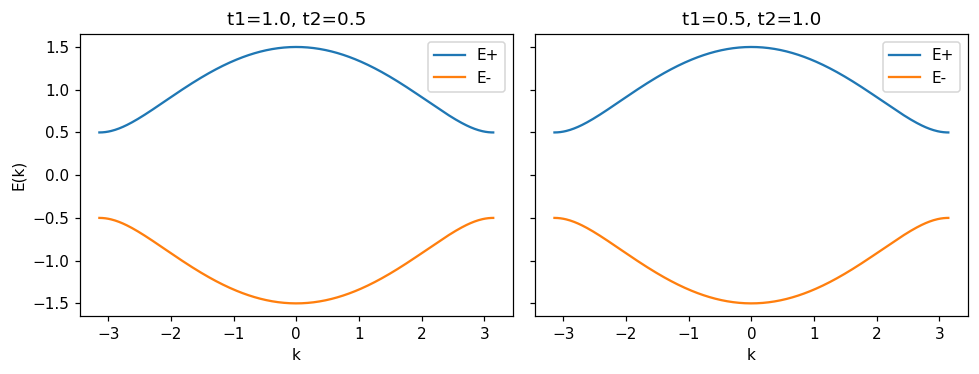

In [4]:
def ssh_hamiltonian(k, t1, t2, a=A_LATTICE):
    off = t1 + t2 * np.exp(1j * k * a)
    return np.array([[0, off], [np.conj(off), 0]], dtype=complex)

def ssh_bands(k_vals, t1, t2):
    Em, Ep = np.zeros(len(k_vals)), np.zeros(len(k_vals))
    for i, k in enumerate(k_vals):
        Em[i], Ep[i] = np.linalg.eigvalsh(ssh_hamiltonian(k, t1, t2))
    return Em, Ep

def verify_ssh(t1, t2, n=50):
    ks = np.linspace(-np.pi, np.pi, n)
    Em, Ep = ssh_bands(ks, t1, t2)
    analytic = np.abs(t1 + t2 * np.exp(1j * ks))
    assert np.allclose(Ep, analytic) and np.allclose(Em, -analytic)
    print(f"검증 통과 (t1={t1}, t2={t2}): 대각화 = 해석식")

verify_ssh(1.0, 0.5)
verify_ssh(0.5, 1.0)

k_vals = np.linspace(-np.pi, np.pi, 400)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for a_, (t1, t2) in zip(ax, [(1.0, 0.5), (0.5, 1.0)]):
    Em, Ep = ssh_bands(k_vals, t1, t2)
    a_.plot(k_vals, Ep, label="E+"); a_.plot(k_vals, Em, label="E-")
    a_.set_title(f"t1={t1}, t2={t2}"); a_.set_xlabel("k"); a_.legend()
ax[0].set_ylabel("E(k)")
plt.tight_layout(); plt.show()

**확인**: 두 그림의 밴드 모양이 **똑같다**. $t_1\leftrightarrow t_2$를 바꿔도 $|t_1+t_2e^{ika}|$의 최솟값·최댓값이 같기 때문이다.
$k=0$에서 $|E|=t_1+t_2$, $k=\pi/a$에서 $|E|=|t_1-t_2|$.

**질문**: 밴드만 보면 두 사슬을 구별할 수 없다. 그럼 두 사슬은 정말 같은 상태인가? (→ 4절)

## 3. 밴드갭

$$E_{gap}=2|t_1-t_2|$$

**예측**: $t_1=t_2$일 때 갭은?

In [5]:
def band_gap(t1, t2):
    return 2 * abs(t1 - t2)

for t1, t2 in [(1.0, 1.0), (1.0, 0.5), (0.5, 1.0), (1.0, 0.9)]:
    # 수치 확인: 대각화로 얻은 밴드에서 직접 갭을 잰다
    Em, Ep = ssh_bands(np.linspace(-np.pi, np.pi, 2001), t1, t2)
    gap_numeric = Ep.min() - Em.max()
    print(f"t1={t1:.1f}, t2={t2:.1f} | 공식 {band_gap(t1,t2):.3f} | 수치 {gap_numeric:.3f}")

t1=1.0, t2=1.0 | 공식 0.000 | 수치 0.000
t1=1.0, t2=0.5 | 공식 1.000 | 수치 1.000
t1=0.5, t2=1.0 | 공식 1.000 | 수치 1.000
t1=1.0, t2=0.9 | 공식 0.200 | 수치 0.200


**확인**: 공식과 수치가 일치. $t_1=t_2$면 갭이 정확히 0(금속적), $t_1\neq t_2$면 열린다.
$(1.0,0.5)$와 $(0.5,1.0)$는 **갭 크기가 똑같다**.

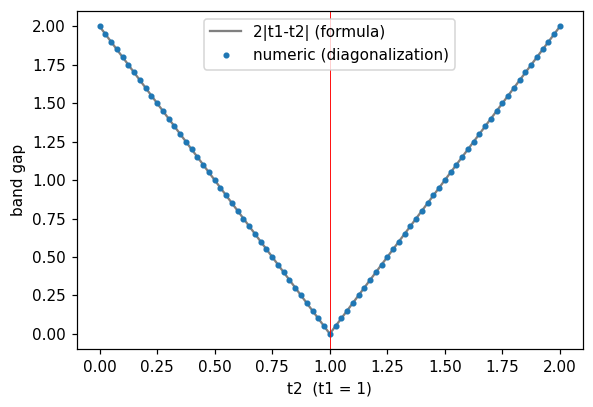

공식과 수치의 최대 차이: 2.4492935982947064e-16
t2 = 1 에서의 갭: 2.4492935982947064e-16
t1=t2 인 SSH 고리 vs 원자 40개 단원자 고리 스펙트럼 최대 차이: 0.0
t1=1, t2=0.5 고리에서 |E|의 최솟값: 0.49999999999999967 (이론: |t1-t2| = 0.5)


In [6]:
# 갭 vs t2 (t1 = 1 고정). 각 점에서 2x2 행렬을 대각화해 갭을 직접 잰다.
def gap_numeric(t1, t2, n_k=2001):
    ks = np.linspace(-np.pi, np.pi, n_k)
    off = t1 + t2 * np.exp(1j * ks)
    H = np.zeros((n_k, 2, 2), dtype=complex); H[:, 0, 1] = off; H[:, 1, 0] = np.conj(off)
    w = np.linalg.eigvalsh(H)
    return w[:, 1].min() - w[:, 0].max()

t2_grid = np.linspace(0, 2, 81)
g_num = np.array([gap_numeric(1.0, t2) for t2 in t2_grid])
g_ana = 2 * np.abs(1.0 - t2_grid)

plt.figure(figsize=(5.5, 3.8))
plt.plot(t2_grid, g_ana, "-", color="gray", label="2|t1-t2| (formula)")
plt.plot(t2_grid, g_num, ".", label="numeric (diagonalization)")
plt.axvline(1.0, color="r", lw=0.6)
plt.xlabel("t2  (t1 = 1)"); plt.ylabel("band gap"); plt.legend(); plt.tight_layout(); plt.show()
print("공식과 수치의 최대 차이:", np.max(np.abs(g_num - g_ana)))
print("t2 = 1 에서의 갭:", g_num[np.argmin(np.abs(t2_grid - 1.0))])

# t1 = t2 이면 단원자 사슬과 같은가? 주기경계 고리의 스펙트럼으로 비교 (원자 40개)
def ssh_ring(n_cells, t1, t2):
    N = 2 * n_cells; H = np.zeros((N, N))
    for n in range(N):
        t = t1 if n % 2 == 0 else t2                      # 결합이 t1, t2 번갈아
        H[n, (n + 1) % N] = H[(n + 1) % N, n] = t
    return H
E_ssh_eq = np.sort(np.linalg.eigvalsh(ssh_ring(20, 1.0, 1.0)))
E_chain = np.sort(np.linalg.eigvalsh(-ring_hamiltonian(40, 1.0)))   # 홉핑 부호만 맞춘 단원자 고리 (원자 40개)
print("t1=t2 인 SSH 고리 vs 원자 40개 단원자 고리 스펙트럼 최대 차이:", np.max(np.abs(E_ssh_eq - E_chain)))
E_ssh_gap = np.linalg.eigvalsh(ssh_ring(20, 1.0, 0.5))
print("t1=1, t2=0.5 고리에서 |E|의 최솟값:", np.min(np.abs(E_ssh_gap)), "(이론: |t1-t2| = 0.5)")

**확인**
- 갭 $=2|t_1-t_2|$이 $t_2$ 전 구간에서 수치와 일치하고, $t_2=t_1$에서 정확히 0이 된다(V자 모양).
- $t_1=t_2$일 때 SSH 고리의 스펙트럼은 같은 원자 수의 단원자 고리와 같다. 즉 갭이 닫힌 SSH는 **균일한 사슬로 되돌아간다**.
- $t_1\neq t_2$이면 $E=0$ 근처가 비고 $|E|_{min}=|t_1-t_2|$ — 갭의 절반이다.

## 4. 위상수 (winding number)

$H(k)=d_x(k)\sigma_x+d_y(k)\sigma_y$ 로 쓰면

$$d_x=t_1+t_2\cos ka,\qquad d_y=t_2\sin ka$$

$\mathbf d(k)$가 브릴루앙 영역을 한 바퀴 도는 동안 **원점을 몇 번 감는가**가 위상수 $\nu$다.
$\mathbf d(k)$는 중심 $(t_1,0)$, 반지름 $t_2$인 원이므로, 원점을 품는가는 $t_2>t_1$인가와 같다.

**예측**: $(t_1,t_2)=(1,0.5)$와 $(0.5,1)$ 중 원점을 감는 쪽은?

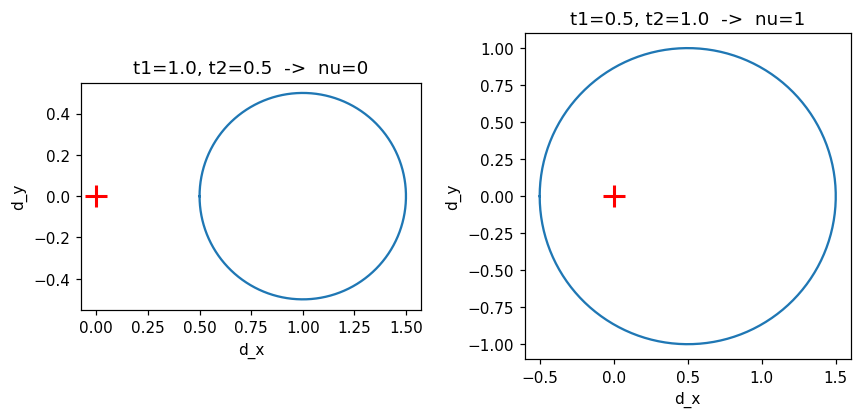

t1=1.0, t2=0.5  ->  nu = 0   (기대: 0)
t1=0.5, t2=1.0  ->  nu = 1   (기대: 1)
t1=2.0, t2=1.0  ->  nu = 0   (기대: 0)
t1=1.0, t2=3.0  ->  nu = 1   (기대: 1)


In [7]:
def winding_number(t1, t2, n_k=4000):
    k = np.linspace(-np.pi, np.pi, n_k, endpoint=False)
    d = (t1 + t2 * np.cos(k)) + 1j * (t2 * np.sin(k))     # d_x + i d_y
    # 닫힌 곡선: 이웃한 점 사이의 각도 증분(-pi~pi)을 전부 더한다
    dtheta = np.angle(np.roll(d, -1) / d)
    return int(round(dtheta.sum() / (2 * np.pi)))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))
kk = np.linspace(-np.pi, np.pi, 400)
for a_, (t1, t2) in zip(ax, [(1.0, 0.5), (0.5, 1.0)]):
    a_.plot(t1 + t2*np.cos(kk), t2*np.sin(kk))
    a_.plot(0, 0, "r+", ms=14, mew=2)
    a_.set_aspect("equal"); a_.set_xlabel("d_x"); a_.set_ylabel("d_y")
    a_.set_title(f"t1={t1}, t2={t2}  ->  nu={winding_number(t1, t2)}")
plt.tight_layout(); plt.show()

for t1, t2 in [(1.0, 0.5), (0.5, 1.0), (2.0, 1.0), (1.0, 3.0)]:
    print(f"t1={t1}, t2={t2}  ->  nu = {winding_number(t1, t2)}   (기대: {1 if t2 > t1 else 0})")

**확인**: $t_2>t_1$이면 $\nu=1$(원이 원점을 감음), $t_1>t_2$이면 $\nu=0$.

**핵심**: 갭이 열려 있는 한($\mathbf d$가 원점을 안 지나는 한) 이 곡선이 원점을 감는 횟수는 정수이며, $t_1,t_2$를 연속적으로 바꿔도 변하지 않는다.
$\nu$가 바뀌려면 곡선이 원점을 지나야 하고, 그건 정확히 $t_1=t_2$(갭이 닫히는 순간)다.

### 4-2. Zak phase를 직접 계산하기

위상수는 $\mathbf d(k)$의 회전수였다. 같은 정보를 **Berry 위상**으로도 얻을 수 있다.

$$\gamma=i\oint_{BZ}\langle u_k|\partial_k u_k\rangle\,dk$$

수치로는 $k$를 $N_k$개로 나누고, 아래 밴드 고유벡터의 이웃한 겹침을 곱해 위상을 읽는다(고유벡터의 임의 위상에 영향받지 않는 형태).

$$\gamma=-\operatorname{Im}\ln\prod_{j}\langle u_{k_j}|u_{k_{j+1}}\rangle$$

**예측**: 자명한 사슬과 비자명한 사슬에서 $\gamma$는 각각 얼마인가?

  t1   t2 |  |Zak|/pi | winding nu


 1.0  0.5 |    0.0000 |          0
 0.5  1.0 |    1.0000 |          1
 2.0  1.0 |    0.0000 |          0
 1.0  3.0 |    1.0000 |          1
스캔한 t2 개수: 39
|Zak|/pi 가 0 또는 1 에서 벗어난 최대량: 4.440892098500626e-16
t2 < 1 인 점에서의 값 범위: 0.0 ~ 1.6808590181141065e-16
t2 > 1 인 점에서의 값 범위: 0.9999999999999996 ~ 1.0


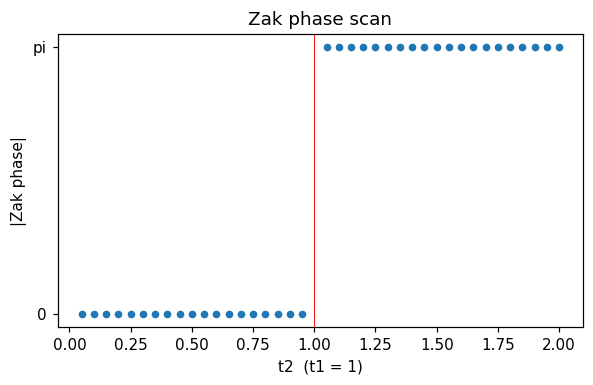

In [8]:
def zak_phase(t1, t2, n_k=400):
    ks = np.linspace(-np.pi, np.pi, n_k, endpoint=False)
    us = [np.linalg.eigh(ssh_hamiltonian(k, t1, t2))[1][:, 0] for k in ks]     # 아래 밴드
    prod = 1 + 0j
    for j in range(n_k):
        prod *= np.vdot(us[j], us[(j + 1) % n_k])          # 닫힌 고리: 마지막은 처음과 연결
    return -np.angle(prod)

print(f"{'t1':>4} {'t2':>4} | {'|Zak|/pi':>9} | {'winding nu':>10}")
for t1, t2 in [(1.0, 0.5), (0.5, 1.0), (2.0, 1.0), (1.0, 3.0)]:
    g = zak_phase(t1, t2)
    print(f"{t1:4.1f} {t2:4.1f} | {abs(g)/np.pi:9.4f} | {winding_number(t1, t2):10d}")

# t1 = 1 고정, t2 를 0.05 ~ 2 로 스캔: Zak phase 가 0 또는 pi 로 양자화되고 t2 = t1 에서 뛰는지 확인
t2_scan = np.linspace(0.05, 2.0, 40)
t2_scan = t2_scan[np.abs(t2_scan - 1.0) > 1e-9]          # 갭이 닫히는 t2 = 1 은 제외 (위상수가 정의되지 않음)
zak_scan = np.array([abs(zak_phase(1.0, t2)) / np.pi for t2 in t2_scan])
print("스캔한 t2 개수:", len(t2_scan))
print("|Zak|/pi 가 0 또는 1 에서 벗어난 최대량:", np.max(np.minimum(np.abs(zak_scan), np.abs(zak_scan - 1))))
print("t2 < 1 인 점에서의 값 범위:", zak_scan[t2_scan < 1].min(), "~", zak_scan[t2_scan < 1].max())
print("t2 > 1 인 점에서의 값 범위:", zak_scan[t2_scan > 1].min(), "~", zak_scan[t2_scan > 1].max())

plt.figure(figsize=(5.5, 3.6))
plt.plot(t2_scan, zak_scan, "o", ms=4)
plt.axvline(1.0, color="r", lw=0.6)
plt.yticks([0, 1], ["0", "pi"]); plt.xlabel("t2  (t1 = 1)"); plt.ylabel("|Zak phase|")
plt.title("Zak phase scan"); plt.tight_layout(); plt.show()

**확인**: $|\gamma|/\pi$가 위상수 $\nu$와 같은 값(0 또는 1)으로 나온다. $t_2$를 스캔하면 $t_2<t_1$에서 0, $t_2>t_1$에서 $\pi$로 **양자화**되어 있고, 값이 바뀌는 곳은 갭이 닫히는 $t_2=t_1$ 한 점뿐이다. 즉 $\gamma=\pi\nu \pmod{2\pi}$.
$\gamma$의 **부호는 규약(위상 방향, 단위셀 원점)에 따라 달라지므로** 크기만 비교했다. 같은 이유로 $t_1\leftrightarrow t_2$를 바꾸면(단위셀을 다르게 자르면) $\gamma$가 $0\leftrightarrow\pi$로 뒤바뀐다 — 5절의 "A 사이트로 시작, 셀 안 결합 $t_1$" 규약이 필요한 이유다.

## 5. 유한 사슬과 에지 상태

Bloch 정리는 무한 주기계에만 적용되므로, 끝이 있는 사슬은 **실공간 해밀토니안**을 직접 만들어 대각화한다.
사슬은 A 사이트로 시작하고 셀 안 결합을 $t_1$로 둔다(이 규약이 바뀌면 자명/비자명이 뒤바뀐다).

**예측**: 어느 사슬에서 $E\approx0$ 상태가 나타나는가? 몇 개인가?

trivial (nu=0): E=0 근처 상태 0개, 가장 가까운 두 에너지 = [ 0.5101 -0.5101]
non-trivial (nu=1): E=0 근처 상태 2개, 가장 가까운 두 에너지 = [-0.  0.]


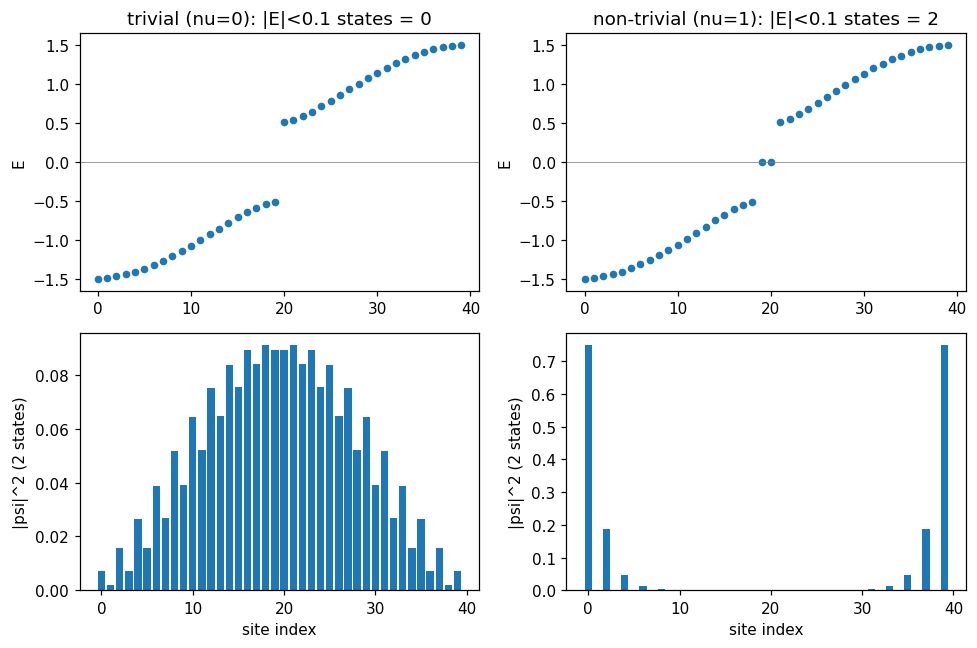

In [9]:
def finite_ssh(n_cells, t1, t2):
    n = 2 * n_cells
    H = np.zeros((n, n))
    for c in range(n_cells):
        H[2*c, 2*c+1] = H[2*c+1, 2*c] = t1          # 셀 안: A_c - B_c
    for c in range(n_cells - 1):
        H[2*c+1, 2*c+2] = H[2*c+2, 2*c+1] = t2      # 셀 간: B_c - A_{c+1}
    return H

N_CELLS = 20
fig, ax = plt.subplots(2, 2, figsize=(9, 6))
for col, (t1, t2, name) in enumerate([(1.0, 0.5, "trivial (nu=0)"), (0.5, 1.0, "non-trivial (nu=1)")]):
    E, V = np.linalg.eigh(finite_ssh(N_CELLS, t1, t2))
    n_zero = int(np.sum(np.abs(E) < 0.1))
    ax[0, col].plot(E, "o", ms=4); ax[0, col].axhline(0, color="gray", lw=0.5)
    ax[0, col].set_title(f"{name}: |E|<0.1 states = {n_zero}")
    ax[0, col].set_ylabel("E")
    # E=0에 가장 가까운 상태 2개의 확률밀도 합
    idx = np.argsort(np.abs(E))[:2]
    dens = np.sum(np.abs(V[:, idx])**2, axis=1)
    ax[1, col].bar(range(len(dens)), dens)
    ax[1, col].set_xlabel("site index"); ax[1, col].set_ylabel("|psi|^2 (2 states)")
    print(f"{name}: E=0 근처 상태 {n_zero}개, 가장 가까운 두 에너지 = {np.round(E[idx], 5)}")
plt.tight_layout(); plt.show()

**확인**
- 비자명($t_2>t_1$): $E\approx0$ 상태 **2개**, 확률밀도가 사슬 **양 끝**에만 몰려 있음
- 자명($t_1>t_2$): $E\approx0$ 상태 **0개**

손으로 푼 결과와 비교: 반무한 사슬에서 $\psi_{A,n}=(-t_1/t_2)^{n-1}\psi_{A,1}$ 이고 $|t_1/t_2|<1$일 때만 규격화된다.
국소화 길이 $\xi=a/\ln(t_2/t_1)$ — 아래에서 수치로 확인한다.

수치로 얻은 인접 A사이트 진폭비: [0.5 0.5 0.5 0.5 0.5]
이론 t1/t2                    : 0.5


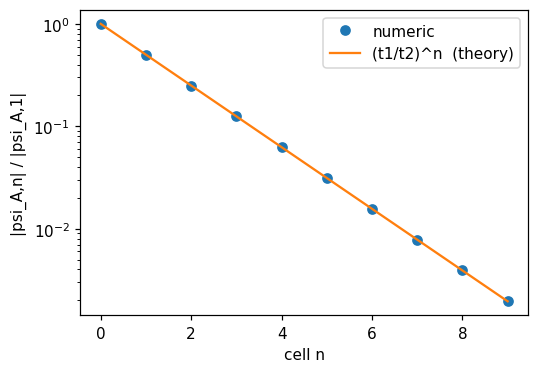

In [10]:
# 이론 예측 |psi_A,n| ∝ (t1/t2)^(n-1) 과 수치 결과 비교 (왼쪽 끝 에지 상태)
t1, t2 = 0.5, 1.0
N_CELLS = 30
E, V = np.linalg.eigh(finite_ssh(N_CELLS, t1, t2))
i0, i1 = np.argsort(np.abs(E))[:2]
# 두 영모드의 합/차로 왼쪽·오른쪽 끝 상태를 분리
left = V[:, i0] + V[:, i1]; left /= np.linalg.norm(left)
if abs(left[0]) < abs(left[-1]):
    left = V[:, i0] - V[:, i1]; left /= np.linalg.norm(left)
amp_A = np.abs(left[0::2])                      # A 사이트 진폭
n = np.arange(10)
ratio_num = amp_A[1:10] / amp_A[0:9]
print("수치로 얻은 인접 A사이트 진폭비:", np.round(ratio_num[:5], 4))
print("이론 t1/t2                    :", t1 / t2)

plt.figure(figsize=(5, 3.5))
plt.semilogy(n, amp_A[:10] / amp_A[0], "o", label="numeric")
plt.semilogy(n, (t1 / t2) ** n, "-", label="(t1/t2)^n  (theory)")
plt.xlabel("cell n"); plt.ylabel("|psi_A,n| / |psi_A,1|"); plt.legend()
plt.tight_layout(); plt.show()

**확인**: 진폭이 셀마다 $t_1/t_2=0.5$배씩 지수적으로 줄어든다 — 이론의 $(−t_1/t_2)^{n-1}$ 크기와 일치.

---
## 6. 정리

| 질문 | 답 | 근거(셀) |
|---|---|---|
| 해석식은 맞는가 | $N\times N$ 대각화가 기계 정밀도로 일치 | 1-2절 |
| 밴드만으로 두 사슬을 구별할 수 있는가 | 불가 (밴드·갭 동일) | 2, 3절 |
| 무엇이 구별하는가 | 위상수 $\nu$ ($\mathbf d(k)$가 원점을 감는 횟수) = Zak phase$/\pi$ | 4, 4-2절 |
| 관측 가능한 차이는 | $\nu=1$일 때만 끝에 $E\approx0$ 에지 상태 2개 | 5절 |
| 왜 보호되는가 | $\nu$는 정수 → $t_1=t_2$(갭 닫힘)를 지나야만 변함 | 4절 |